### <font color=#0000FF>【自行練習】波士頓房價預測</font>

【Housing】Dataset

- CRIM: Per capita crime rate by town 
    - 按城鎮劃分的人均犯罪率
- ZN: Proportion of residential land zoned for lots over 25,000 sq. ft 
    - 劃定面積超過25,000平方英尺的住宅用地比例
- INDUS: Proportion of non-retail business acres per town 
    - 每個城鎮非零售業務英畝的比例
- CHAS: Charles River dummy variable (= 1 if tract bounds river and 0 otherwise)
    - Charles River虛擬變量（如果區域限制河流，則為1，否則為0）
- NOX: Nitric oxide concentration (parts per 10 million)
    - 一氧化氮濃度（百萬分之幾）
- RM: Average number of rooms per dwelling
    - 每個住宅的平均房間數
- AGE: Proportion of owner-occupied units built prior to 1940
    - 1940年之前建造的自有住房的比例
- DIS: Weighted distances to five Boston employment centers
    - 到五個波士頓就業中心的加權距離
- RAD: Index of accessibility to radial highways
    - 徑向公路的可達性指數
- TAX: Full-value property tax rate per \\$10,000
    - 每 \\$ 10,000美元的全值財產稅率
- PTRATIO: Pupil-teacher ratio by town
    - 各鎮的師生比例
- B: $1000（Bk – 0.63）^2$ , where Bk is the proportion of [people of African American descent] by town
    - $1000（Bk – 0.63）^2$，其中Bk是[非裔美國人]按城鎮劃分的比例
- LSTAT: Percentage of lower status of the population
    - 低等人口百分比
- MEDV: Median value of owner-occupied homes in \\$1000s
    - 自有住房的中位數價值為1000美元

### <font color = "blue">step1:載入資料</font>

In [1]:
import pandas as pd

uri = "https://raw.githubusercontent.com/rasbt/python-machine-learning-book-3rd-edition/master/ch10/housing.data.txt"
colnames = ['CRIM', 'ZN', 'INDUS', 'CHAS', 
            'NOX', 'RM', 'AGE', 'DIS', 'RAD', 
            'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

bh = pd.read_csv(uri, sep=r"\s+", names = colnames)

print(bh.shape)
print(bh.info())
bh.head(5)

(506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### <font color = "blue">step2:縱向切割資料</font>

In [2]:
X = bh.iloc[:, :-1]
y = bh["MEDV"]

### <font color = "blue">step3:train, test資料集</font>

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    shuffle=True,
)

### <font color = "blue">step4:建立模型</font>

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler #標準化
from sklearn.pipeline import make_pipeline

In [6]:
model = make_pipeline(
    StandardScaler(), #標準化
    LinearRegression(
    fit_intercept=True,
    copy_X=True,
    tol=1e-06,
    n_jobs=-1,
    positive=False,)
                     )

### <font color = "blue">step5:訓練模型</font>

In [7]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1


### <font color = "blue">step6:驗證模型，使用RMSE、Ｒ2、MAE</font>

In [8]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("train")
print(f"R2 : {r2_score(y_train, y_train_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_train, y_train_pred):.3f}")
print(f"RMSE : {root_mean_squared_error(y_train, y_train_pred):.3f}")
print("-" * 20)
print("test")
print(f"R2 : {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"RMSE : {root_mean_squared_error(y_test, y_test_pred):.3f}")

train
R2 : 0.739
MAE : 3.376
RMSE : 4.794
--------------------
test
R2 : 0.726
MAE : 3.148
RMSE : 4.552


In [10]:
print(f"y mean : {y.mean():.3f}")
print(f"price 誤差 : {int(4500/22000*100)}%")

y mean : 22.533
price 誤差 : 20%


### <font color = "blue">cross validatioin 交叉驗證</font>

In [23]:
from sklearn.model_selection import cross_val_score 
from sklearn.model_selection import KFold

kf = KFold(n_splits = 5, shuffle = True, random_state = 42) #因為cross validation 沒shuffle，這樣資料每筆切分會有問題，所以要用KFold

scores = cross_val_score(model, X, y, cv = kf)

print("CV scores : ", scores)
print("CV mean : ", scores.mean()) #是否與Ｒ2數值相同
print("CV std : ", scores.std()) #越小越好

CV scores :  [0.66875949 0.7342547  0.70986601 0.77595168 0.68727731]
CV mean :  0.7152218388256883
CV std :  0.03746650285569633


### <font color = "blue">Ridge 嶺回歸 穩定模型</font>

In [25]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ridge = make_pipeline(StandardScaler(), Ridge(alpha = 1.0))

r_scores = cross_val_score(ridge, X, y, cv = kf)

print("Ridge score : ", r_scores)
print("Ridge mean : ", r_scores.mean())
print("Ridge std : ", r_scores.std())

Ridge score :  [0.66846244 0.7341491  0.70958537 0.77610626 0.68790013]
Ridge mean :  0.71524065836605
Ridge std :  0.03749623695013412


### <font color = "blue">lasso 特徵選擇</font>

In [32]:
from sklearn.linear_model import Lasso

lasso = make_pipeline(StandardScaler(), Lasso(alpha = 0.1))

l_scores = cross_val_score(lasso, X, y, cv = kf)

print("Lasso score : ", l_scores)
print("Lasso mean : ", l_scores.mean())
print("Lasso std : ", l_scores.std())

Lasso score :  [0.65013752 0.72603224 0.69981302 0.77442187 0.69453789]
Lasso mean :  0.7089885063401624
Lasso std :  0.04081289583254237


In [34]:
lasso.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [37]:
# 重點lasso可以看出哪些特徵對於模型不是特別重要，只要是0表示不重要

l_coef = lasso.named_steps["lasso"].coef_

for name, c in zip(X.columns, l_coef):
    print(name, c)

CRIM -0.6323036389905302
ZN 0.7084093141987351
INDUS -0.0
CHAS 0.6576072255074006
NOX -1.5741933479022405
RM 2.8262690307935303
AGE -0.0
DIS -2.4220790078781764
RAD 1.1959368149844
TAX -0.8464677789680622
PTRATIO -1.9224934488824694
B 0.7621653890824794
LSTAT -3.726183828251559


### <font color = "blue">step7:預測資料</font>

In [13]:
y_test_pred = model.predict(X_test)

print("真實資料", y_test)
print("-" * 60)
print("預測資料", y_test_pred)

真實資料 173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
110    21.7
321    23.1
265    22.8
29     21.0
262    48.8
Name: MEDV, Length: 167, dtype: float64
------------------------------------------------------------
預測資料 [28.53469469 36.6187006  15.63751079 25.5014496  18.7096734  23.16471591
 17.31011035 14.07736367 23.01064388 20.54223482 24.91632351 18.41098052
 -6.52079687 21.83372604 19.14903064 26.0587322  20.30232625  5.74943567
 40.33137811 17.45791446 27.47486665 30.2170757  10.80555625 23.87721728
 17.99492211 16.02608791 23.268288   14.36825207 22.38116971 19.3092068
 22.17284576 25.05925441 25.13780726 18.46730198 16.60405712 17.46564046
 30.71367733 20.05106788 23.9897768  24.94322408 13.97945355 31.64706967
 42.48057206 17.70042814 26.92507869 17.15897719 13.68918087 26.14924245
 20.2782306  29.99003492 21.21260347 34.03649185 15.41837553 25.95781061
 39.13897274 22.96118424 18.80310558 33.07865362 24.74384155 12.83640958
 22.41963398 30.64804979 31.

In [14]:
coef = model.named_steps["linearregression"].coef_ #提取coef資料 因為前面用了pipeline

coef_df = pd.DataFrame(
    {"feature" : X.columns,
    "coef" : coef}
).sort_values("coef", ascending = False)

print(coef_df)

    feature      coef
5        RM  2.808135
8       RAD  2.032761
11        B  1.041257
1        ZN  0.867933
3      CHAS  0.861838
2     INDUS  0.405028
6       AGE -0.358669
0      CRIM -0.988580
9       TAX -1.364009
4       NOX -1.900100
10  PTRATIO -2.082536
7       DIS -3.045535
12    LSTAT -3.926286


### <font color = "blue">預測 vs 真實 判別模型到底好不好</font>

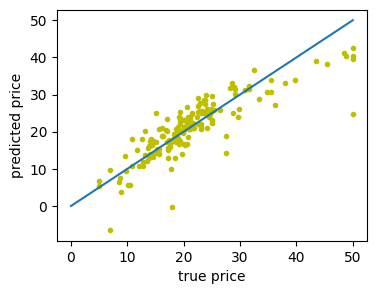

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize = [4, 3])
plt.scatter(x = y_test, y = y_test_pred, c = "y", marker = ".")
plt.xlabel("true price")
plt.ylabel("predicted price")
plt.plot([0, 50], [0, 50])

plt.show()

### <font color = "blue">殘差圖</font>

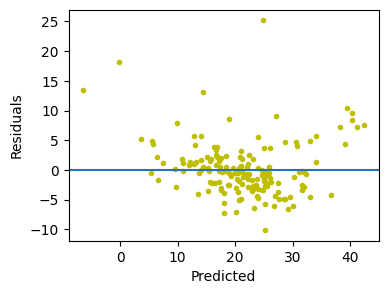

In [17]:
residuals = y_test - y_test_pred

plt.figure(figsize = [4, 3])
plt.scatter(y_test_pred, residuals, marker = ".", c = "y")
plt.xlabel("Predicted") #預測
plt.ylabel("Residuals") #殘差
plt.axhline(y = 0)

plt.show()